# 03. Comprehensive experiment analysis

여러 training seed의 Baseline, Shared-Detach, Shared-E2E, Separate-E2E 결과를 통합 분석합니다. 학습은 수행하지 않으며, 상세 COCO 평가는 checkpoint별 inference 결과를 캐시합니다.

저장 파일은 `comprehensive_summary.csv`, `comprehensive_metrics.csv`, `comprehensive_analysis.png` 세 개로 제한합니다.

In [1]:
from pathlib import Path
import gc, importlib, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists(): ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import gt_aux.config as config_module
import gt_aux.data as data_module
import gt_aux.eval as eval_module
config_module = importlib.reload(config_module)
data_module = importlib.reload(data_module)
eval_module = importlib.reload(eval_module)
ExperimentConfig = config_module.ExperimentConfig
ID2LABEL = config_module.ID2LABEL
prepare_data, make_loaders = data_module.prepare_data, data_module.make_loaders
load_checkpoint = eval_module.load_checkpoint

d:\gt-super\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 분석 설정

학습이 완료된 seed만 `SEEDS`에 적습니다. 학습 당시 데이터·해상도 설정과 동일해야 합니다.

In [2]:
RUN_MODE = 'smoke'
SEEDS = [42, 43, 44]
DATA_SEED = 42
EXPERIMENTS = ['baseline', 'shared_detach', 'shared_e2e', 'separate_e2e']
TRAIN_IMAGES, VAL_IMAGES, EPOCHS = 400, 100, 7
BATCH_SIZE, IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 2, 384, 640
FEATURE_LEVEL = 0
RUN_DETAILED_EVALUATION = True  # False면 기존 comprehensive_metrics.csv만 사용
IOU_THRESHOLDS = [round(0.50 + 0.05 * i, 2) for i in range(10)]

CONFIG = ExperimentConfig.for_run(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED, experiments=EXPERIMENTS,
    train_images=TRAIN_IMAGES, val_images=VAL_IMAGES, epochs=EPOCHS, batch_size=BATCH_SIZE,
    image_min_size=IMAGE_MIN_SIZE, image_max_size=IMAGE_MAX_SIZE, feature_level=FEATURE_LEVEL,
)
SUMMARY_PATH = CONFIG.output_dir / 'comprehensive_summary.csv'
METRICS_PATH = CONFIG.output_dir / 'comprehensive_metrics.csv'
FIGURE_PATH = CONFIG.output_dir / 'comprehensive_analysis.png'
CONFIG.as_dict()

{'root': 'D:\\gt-super',
 'run_mode': 'smoke',
 'checkpoint': 'SenseTime/deformable-detr',
 'train_images': 400,
 'val_images': 100,
 'epochs': 7,
 'batch_size': 2,
 'num_workers': 0,
 'image_size': {'shortest_edge': 384, 'longest_edge': 640},
 'lr': 0.0002,
 'backbone_lr': 2e-05,
 'weight_decay': 0.0001,
 'grad_clip': 0.1,
 'base_aux_weight': 0.5,
 'feature_level': 0,
 'horizontal_flip_p': 0.5,
 'use_amp': True,
 'deterministic': True,
 'save_epoch_checkpoints': False,
 'device': 'cuda',
 'experiments': ['baseline', 'shared_detach', 'shared_e2e', 'separate_e2e'],
 'seed': 42,
 'data_seed': 42}

## 1. Run 무결성 및 학습 기록 로드

In [3]:
history_frames, gradient_frames, integrity_rows = [], [], []
for seed in SEEDS:
    for experiment in EXPERIMENTS:
        history_path = CONFIG.history_path(experiment, seed)
        gradient_path = CONFIG.gradients_path(experiment, seed)
        checkpoint_path = CONFIG.checkpoint_path(experiment, seed)
        checkpoint_gradient = pd.DataFrame()
        history_source = 'csv' if history_path.exists() else None
        history = pd.read_csv(history_path) if history_path.exists() else pd.DataFrame()
        if history.empty and checkpoint_path.exists():
            checkpoint_state = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
            history = pd.DataFrame(checkpoint_state.get('history', []))
            checkpoint_gradient = pd.DataFrame(checkpoint_state.get('gradients', []))
            if not history.empty:
                history_source = 'checkpoint'
                if 'data_seed' not in history.columns:
                    history['data_seed'] = checkpoint_state.get('config', {}).get('data_seed', DATA_SEED)
            del checkpoint_state
        if not history.empty:
            history_frames.append(history)
        gradient = pd.DataFrame()
        if gradient_path.exists() and gradient_path.stat().st_size > 0:
            try: gradient = pd.read_csv(gradient_path)
            except pd.errors.EmptyDataError: pass
        if gradient.empty and not checkpoint_gradient.empty:
            gradient = checkpoint_gradient
        if not gradient.empty: gradient_frames.append(gradient)
        observed_data_seed = history['data_seed'].dropna().unique().tolist() if 'data_seed' in history else []
        final_epoch = int(history['epoch'].max()) if not history.empty else None
        integrity_rows.append({
            'experiment': experiment, 'seed': seed, 'history_source': history_source,
            'checkpoint': checkpoint_path.exists(), 'final_epoch': final_epoch,
            'complete': final_epoch == EPOCHS, 'data_seed': observed_data_seed[0] if len(observed_data_seed) == 1 else None,
        })

integrity_df = pd.DataFrame(integrity_rows)
display(integrity_df)
if not history_frames: raise FileNotFoundError('분석할 history CSV가 없습니다.')
history_df = pd.concat(history_frames, ignore_index=True)
gradients_df = pd.concat(gradient_frames, ignore_index=True) if gradient_frames else pd.DataFrame()
if 'data_seed' not in history_df or sorted(history_df['data_seed'].dropna().unique()) != [DATA_SEED]:
    raise ValueError('모든 run은 수정된 코드와 동일한 DATA_SEED로 다시 학습되어야 합니다.')
complete_runs = integrity_df.query('complete and checkpoint')[['experiment', 'seed']]

,experiment,seed,history_source,checkpoint,final_epoch,complete,data_seed
0,baseline,42,csv,True,7,True,42
1,shared_detach,42,csv,True,7,True,42
2,shared_e2e,42,csv,True,7,True,42
3,separate_e2e,42,csv,True,7,True,42
4,baseline,43,csv,True,7,True,42
5,shared_detach,43,csv,True,7,True,42
6,shared_e2e,43,csv,True,7,True,42
7,separate_e2e,43,csv,True,7,True,42
8,baseline,44,csv,True,7,True,42
9,shared_detach,44,csv,True,7,True,42


## 2. 최종 성능 평균·표준편차

In [4]:
final_df = history_df.sort_values('epoch').groupby(['experiment', 'seed'], as_index=False).tail(1).copy()
final_df['localization_ratio'] = final_df['map75'] / final_df['map50'].replace(0, np.nan)
final_df['localization_gap'] = final_df['map50'] - final_df['map75']
metrics = ['map', 'map50', 'map75', 'mar100', 'localization_ratio', 'main_loss', 'train_seconds']
summary_df = final_df.groupby('experiment')[metrics].agg(['mean', 'std', 'count'])
baseline_means = summary_df.loc['baseline'].xs('mean', level=1)
flat_summary = summary_df.copy()
flat_summary.columns = [f'{metric}_{stat}' for metric, stat in flat_summary.columns]
for metric in ['map', 'map50', 'map75', 'mar100']:
    flat_summary[f'{metric}_delta_vs_baseline'] = flat_summary[f'{metric}_mean'] - baseline_means[metric]
flat_summary.to_csv(SUMMARY_PATH)
display(flat_summary)
print('Saved:', SUMMARY_PATH)

,map_mean,map_std,map_count,map50_mean,map50_std,map50_count,map75_mean,map75_std,map75_count,mar100_mean,...,main_loss_mean,main_loss_std,main_loss_count,train_seconds_mean,train_seconds_std,train_seconds_count,map_delta_vs_baseline,map50_delta_vs_baseline,map75_delta_vs_baseline,mar100_delta_vs_baseline
experiment,,,,,,,,,,,,,,,,,,,,,
baseline,0.068845,0.030949,3,0.117897,0.040832,3,0.071832,0.033281,3,0.387978,...,1.512701,0.054023,3,384.848031,8.596061,3,0.000000,0.000000,0.000000,0.000000
separate_e2e,0.078479,0.007391,3,0.127680,0.011895,3,0.087140,0.007738,3,0.431719,...,1.379707,0.034633,3,904.645118,877.967923,3,0.009634,0.009783,0.015308,0.043740
shared_detach,0.076090,0.005782,3,0.127558,0.010153,3,0.079733,0.010863,3,0.399006,...,1.468223,0.043085,3,1819.337972,90.108949,3,0.007245,0.009661,0.007901,0.011027
shared_e2e,0.080148,0.023734,3,0.129905,0.035554,3,0.081530,0.021667,3,0.403591,...,1.352981,0.029972,3,541.396695,275.969899,3,0.011303,0.012008,0.009698,0.015612


Saved: D:\gt-super\outputs\detr_gt_auxiliary\comprehensive_summary.csv


## 3. COCO area·IoU·클래스별 상세 평가

In [5]:
BUNDLE = prepare_data(CONFIG)
_, VAL_LOADER = make_loaders(CONFIG, BUNDLE, CONFIG.seed)

@torch.inference_mode()
def collect_predictions(experiment, seed):
    model, checkpoint, _ = load_checkpoint(CONFIG, BUNDLE, experiment, seed)
    model.eval(); predictions, targets = [], []
    try:
        for batch in tqdm(VAL_LOADER, desc=f'{experiment}/seed{seed}', leave=False):
            result = model(pixel_values=batch['pixel_values'].to(CONFIG.device), pixel_mask=batch['pixel_mask'].to(CONFIG.device), labels=None)
            sizes = torch.stack([target['orig_size'] for target in batch['eval_targets']]).to(CONFIG.device)
            batch_predictions = BUNDLE.processor.post_process_object_detection(result['outputs'], threshold=0.0, target_sizes=sizes)
            predictions.extend([{k: v.detach().cpu() for k, v in item.items()} for item in batch_predictions])
            targets.extend([{'boxes': target['boxes'].cpu(), 'labels': target['labels'].cpu()} for target in batch['eval_targets']])
    finally:
        model.close(); model.cpu(); del model; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    return predictions, targets

def valid_scalar(value):
    value = float(value)
    return np.nan if value < 0 else value

def detailed_metrics(experiment, seed, predictions, targets):
    rows = []
    metric = MeanAveragePrecision(
        box_format='xyxy', iou_type='bbox', class_metrics=True, extended_summary=True,
    )
    metric.update(predictions, targets); result = metric.compute()
    for key, source in [('all','map'), ('small','map_small'), ('medium','map_medium'), ('large','map_large')]:
        rows.append({'experiment':experiment, 'seed':seed, 'metric_type':'area', 'key':key, 'value':valid_scalar(result[source])})
    class_ids = result['classes'].reshape(-1).tolist()
    class_aps = result['map_per_class'].reshape(-1).tolist()
    for class_id, value in zip(class_ids, class_aps):
        rows.append({'experiment':experiment, 'seed':seed, 'metric_type':'class', 'key':ID2LABEL[int(class_id)], 'value':valid_scalar(value)})

    # COCO precision shape: [IoU, recall, class, area, max_detections].
    # area index 0=all, 1=small, 2=medium, 3=large; max_detections=-1 means 100.
    precision = result['precision']
    for class_index, class_id in enumerate(class_ids):
        for scale, area_index in [('small', 1), ('medium', 2), ('large', 3)]:
            values = precision[:, :, class_index, area_index, -1]
            values = values[values >= 0]
            class_scale_ap = float(values.mean()) if values.numel() else np.nan
            rows.append({
                'experiment': experiment, 'seed': seed, 'metric_type': 'class_scale',
                'key': ID2LABEL[int(class_id)], 'scale': scale, 'value': class_scale_ap,
            })
    for threshold in IOU_THRESHOLDS:
        threshold_metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox', iou_thresholds=[threshold])
        threshold_metric.update(predictions, targets)
        rows.append({'experiment':experiment, 'seed':seed, 'metric_type':'iou', 'key':f'{threshold:.2f}', 'value':valid_scalar(threshold_metric.compute()['map'])})
    return rows

cached_df = pd.read_csv(METRICS_PATH) if METRICS_PATH.exists() else pd.DataFrame()
if not cached_df.empty:
    cached_df = cached_df[cached_df['experiment'].isin(EXPERIMENTS) & cached_df['seed'].isin(SEEDS)].copy()
    if 'scale' not in cached_df.columns: cached_df['scale'] = pd.NA
detail_rows = cached_df.to_dict('records') if not cached_df.empty else []
expected_rows_per_run = 4 + len(IOU_THRESHOLDS) + len(ID2LABEL) + 3 * len(ID2LABEL)
cached_pairs = set() if cached_df.empty else set(
    cached_df.groupby(['experiment','seed']).size().loc[lambda count: count >= expected_rows_per_run].index
)
if RUN_DETAILED_EVALUATION:
    for experiment, seed in complete_runs.itertuples(index=False, name=None):
        if (experiment, seed) in cached_pairs: continue
        predictions, targets = collect_predictions(experiment, seed)
        detail_rows.extend(detailed_metrics(experiment, seed, predictions, targets))
detail_df = pd.DataFrame(detail_rows)
if detail_df.empty: raise FileNotFoundError('상세 평가 cache가 없습니다. RUN_DETAILED_EVALUATION=True로 실행하세요.')
if 'scale' not in detail_df.columns: detail_df['scale'] = pd.NA
detail_df['_scale_key'] = detail_df['scale'].fillna('all')
detail_df = detail_df.drop_duplicates(['experiment','seed','metric_type','key','_scale_key'], keep='last')
detail_df = detail_df.drop(columns='_scale_key')
detail_df.to_csv(METRICS_PATH, index=False)
print('Saved:', METRICS_PATH)

VOC XML: 100%|██████████| 3750/3750 [00:06<00:00, 565.66it/s]

Full split: train=3000 (9180 objects), val=750 (2530 objects)
Current run: train=400, val=100
Saved: D:\gt-super\outputs\detr_gt_auxiliary\comprehensive_metrics.csv


## 3-1. 클래스 × 객체 크기별 AP

각 값은 해당 클래스와 COCO 크기 구간을 동시에 만족하는 GT에 대한 AP@[0.50:0.95]입니다. 표의 값은 완료된 seed 평균이며, 유효한 GT가 없는 조합은 NaN으로 표시됩니다.

In [6]:
SCALE_ORDER = ['small', 'medium', 'large']
CLASS_ORDER = [ID2LABEL[class_id] for class_id in sorted(ID2LABEL)]
class_scale_rows = detail_df.query("metric_type == 'class_scale'").copy()
if class_scale_rows.empty:
    raise RuntimeError('AP(class, scale)이 cache에 없습니다. RUN_DETAILED_EVALUATION=True로 위 셀을 다시 실행하세요.')

class_scale_summary = (
    class_scale_rows.groupby(['experiment', 'key', 'scale'], as_index=False)['value']
    .agg(['mean', 'std', 'count']).reset_index()
)
class_scale_mean = class_scale_summary.pivot(
    index='key', columns=['experiment', 'scale'], values='mean',
).reindex(index=CLASS_ORDER)
class_scale_mean = class_scale_mean.reindex(
    columns=pd.MultiIndex.from_product([EXPERIMENTS, SCALE_ORDER], names=['experiment', 'scale'])
)
display(class_scale_mean.style.format('{:.4f}', na_rep='—').set_caption('AP(class, scale): seed mean'))

for experiment in EXPERIMENTS:
    experiment_table = class_scale_mean[experiment].reindex(columns=SCALE_ORDER)
    display(experiment_table.style.format('{:.4f}', na_rep='—').set_caption(f'{experiment}: AP(class, scale)'))

scale,small,medium,large
key,,,
aeroplane,—,—,0.0935
bicycle,—,0.1055,0.1006
bird,—,0.0915,0.0131
boat,—,0.0000,0.0215
bottle,0.0000,—,0.5024
bus,0.0000,0.0505,0.0186
car,0.2185,0.4517,0.2884
cat,—,—,0.0582
chair,—,0.1966,0.0966


scale,small,medium,large
key,,,
aeroplane,—,—,0.0803
bicycle,—,0.0350,0.0816
bird,—,0.0579,0.0236
boat,—,0.0000,0.0076
bottle,0.0000,—,0.3535
bus,0.0000,0.0858,0.0173
car,0.1948,0.3753,0.1936
cat,—,—,0.1534
chair,—,0.1733,0.0958


scale,small,medium,large
key,,,
aeroplane,—,—,0.1228
bicycle,—,0.0460,0.1389
bird,—,0.4455,0.0459
boat,—,0.0000,0.0047
bottle,0.0000,—,0.4081
bus,0.0000,0.0524,0.0114
car,0.2806,0.4489,0.2696
cat,—,—,0.2236
chair,—,0.1887,0.0973


scale,small,medium,large
key,,,
aeroplane,—,—,0.0959
bicycle,—,0.0628,0.0816
bird,—,0.2995,0.0204
boat,—,0.0000,0.0213
bottle,0.0000,—,0.2949
bus,0.0000,0.1711,0.0219
car,0.1854,0.3735,0.1814
cat,—,—,0.1717
chair,—,0.2081,0.1416


## 4. 통합 그래프

Saved: D:\gt-super\outputs\detr_gt_auxiliary\comprehensive_analysis.png


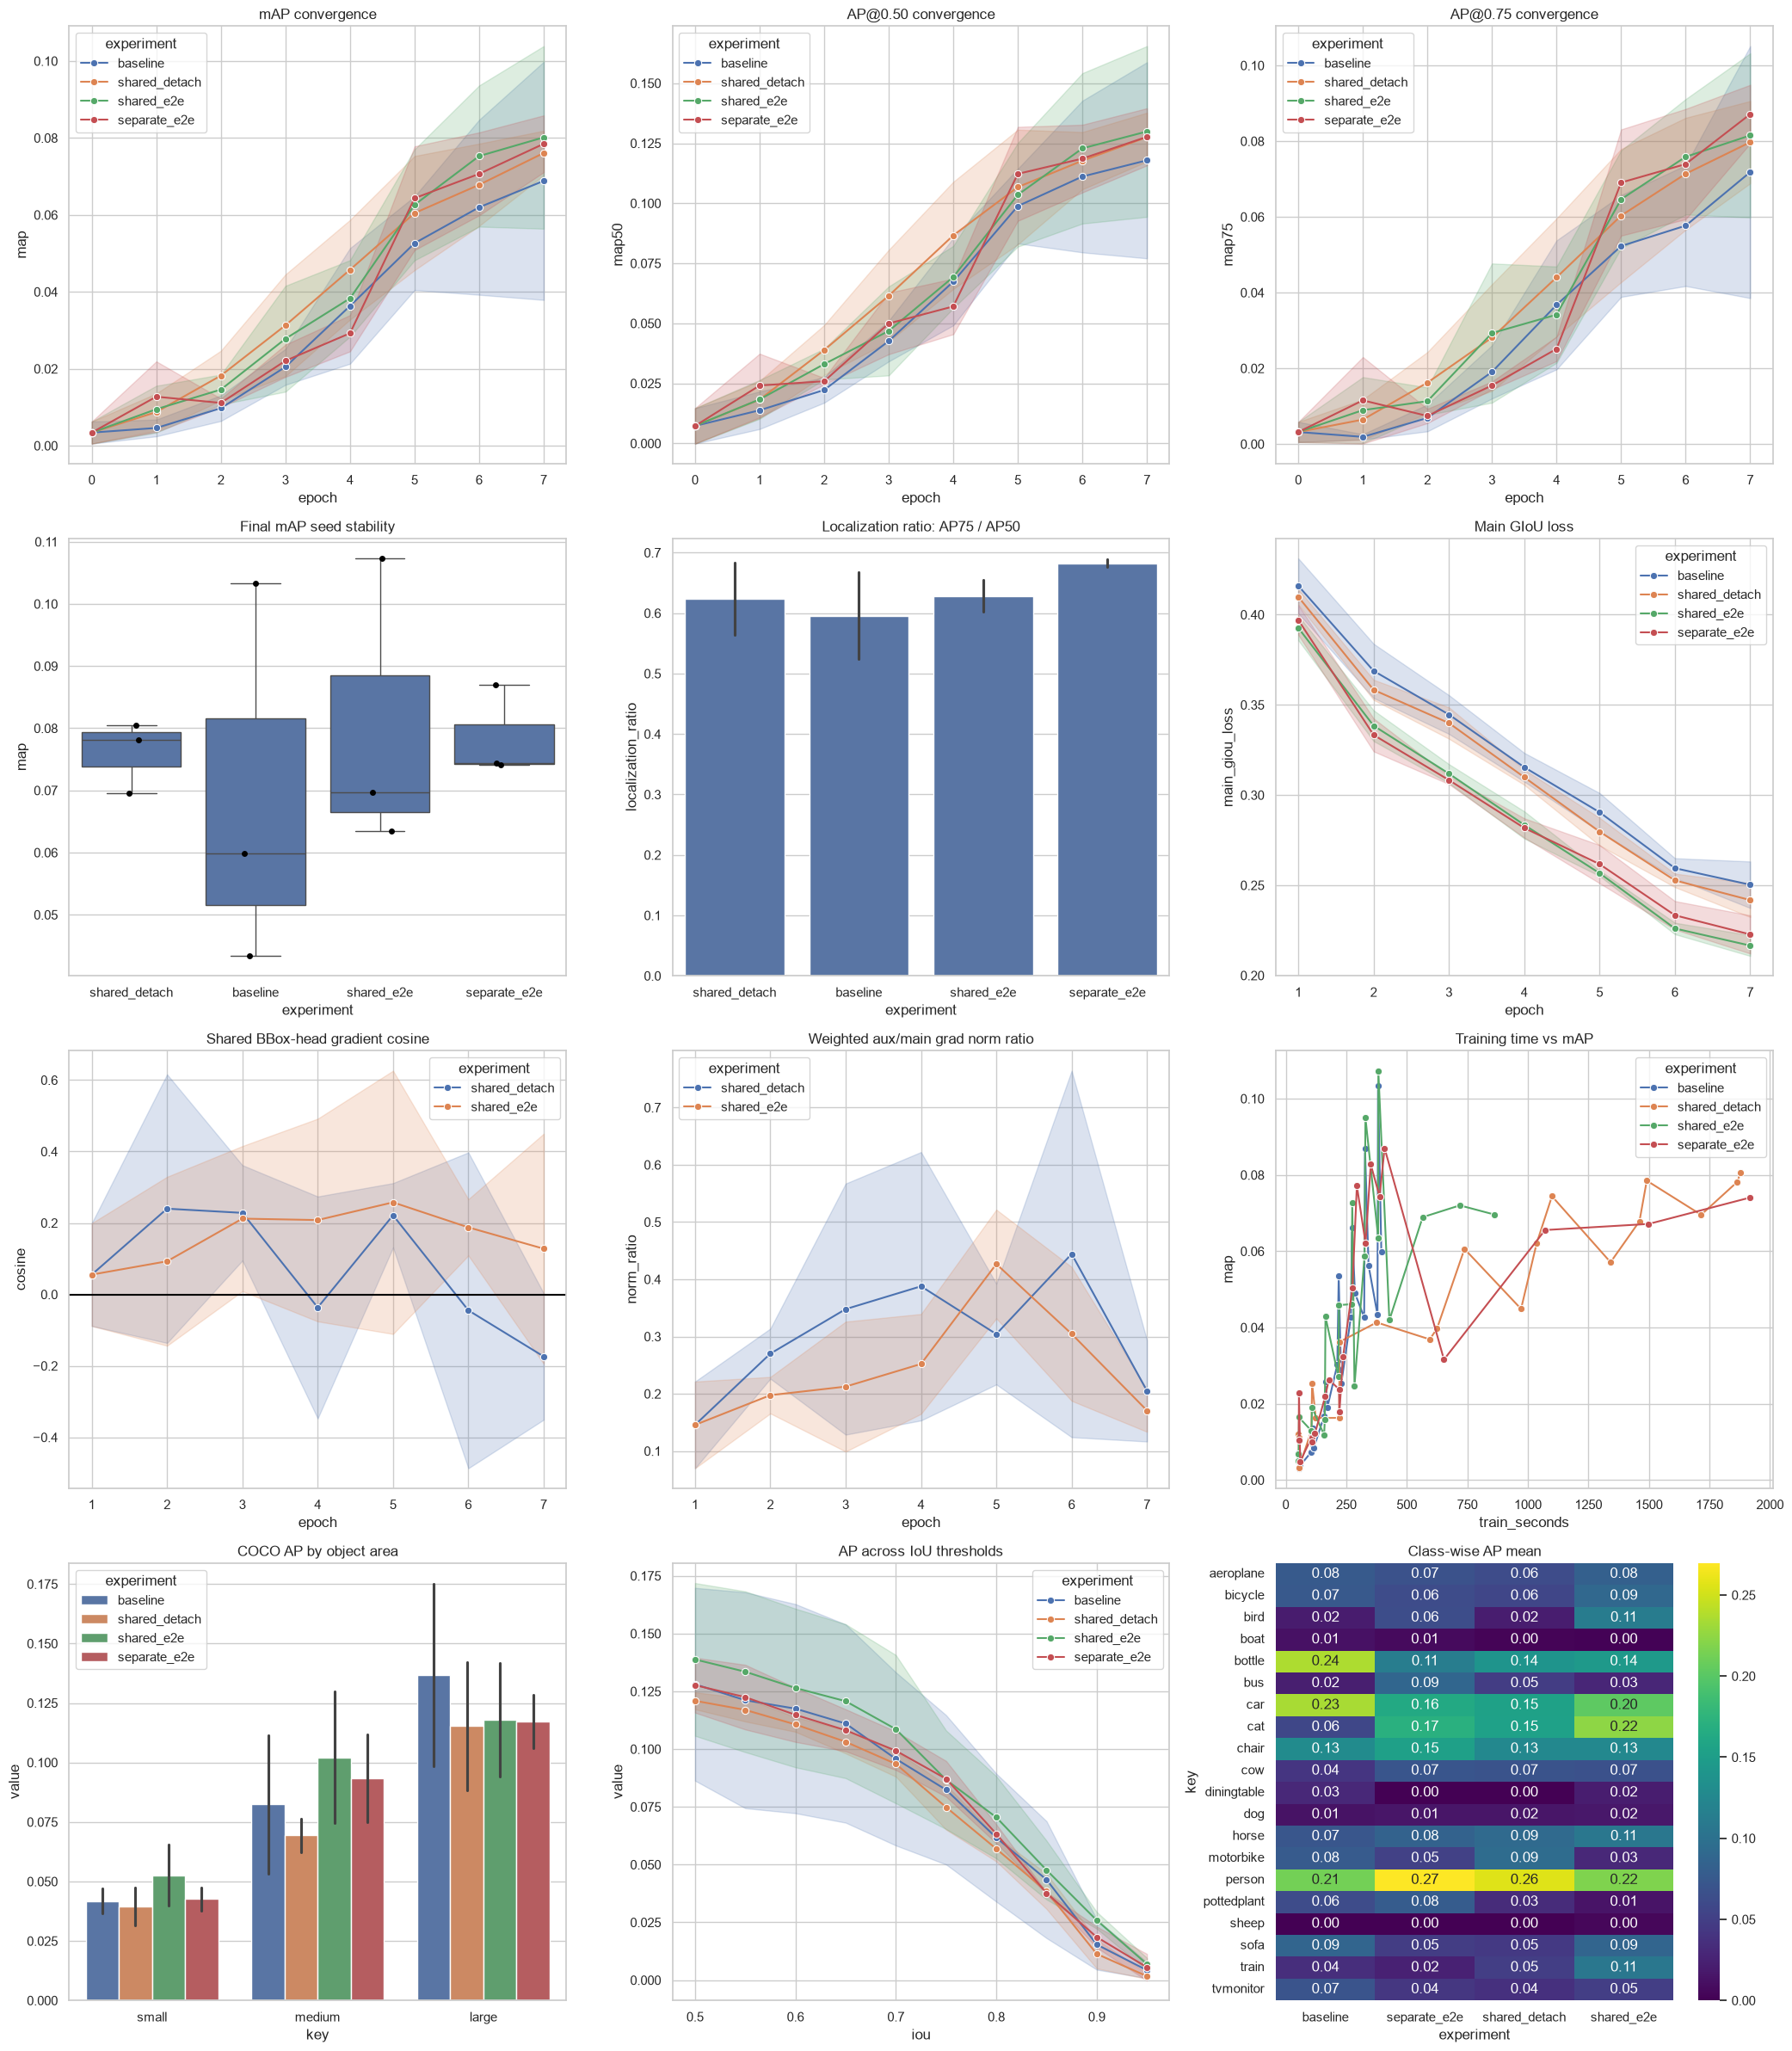

In [7]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(4, 3, figsize=(21, 24))
plot_specs = [('map','mAP convergence'), ('map50','AP@0.50 convergence'), ('map75','AP@0.75 convergence')]
for axis, (metric, title) in zip(axes[0], plot_specs):
    sns.lineplot(data=history_df, x='epoch', y=metric, hue='experiment', estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axis)
    axis.set_title(title)
sns.boxplot(data=final_df, x='experiment', y='map', ax=axes[1,0]); sns.stripplot(data=final_df, x='experiment', y='map', color='black', ax=axes[1,0]); axes[1,0].set_title('Final mAP seed stability')
sns.barplot(data=final_df, x='experiment', y='localization_ratio', errorbar='sd' if len(SEEDS)>1 else None, ax=axes[1,1]); axes[1,1].set_title('Localization ratio: AP75 / AP50')
sns.lineplot(data=history_df.query('epoch > 0'), x='epoch', y='main_giou_loss', hue='experiment', estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axes[1,2]); axes[1,2].set_title('Main GIoU loss')
if not gradients_df.empty:
    sns.lineplot(data=gradients_df, x='epoch', y='cosine', hue='experiment', estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axes[2,0]); axes[2,0].axhline(0,color='black'); axes[2,0].set_title('Shared BBox-head gradient cosine')
    sns.lineplot(data=gradients_df, x='epoch', y='norm_ratio', hue='experiment', estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axes[2,1]); axes[2,1].set_title('Weighted aux/main grad norm ratio')
time_df = history_df.query('epoch > 0')
sns.lineplot(data=time_df, x='train_seconds', y='map', hue='experiment', estimator='mean', marker='o', ax=axes[2,2]); axes[2,2].set_title('Training time vs mAP')
area_df = detail_df.query("metric_type == 'area' and key != 'all'")
sns.barplot(data=area_df, x='key', y='value', hue='experiment', errorbar='sd' if len(SEEDS)>1 else None, ax=axes[3,0]); axes[3,0].set_title('COCO AP by object area')
iou_df = detail_df.query("metric_type == 'iou'").copy(); iou_df['iou'] = iou_df['key'].astype(float)
sns.lineplot(data=iou_df, x='iou', y='value', hue='experiment', estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axes[3,1]); axes[3,1].set_title('AP across IoU thresholds')
class_df = detail_df.query("metric_type == 'class'").groupby(['key','experiment'])['value'].mean().unstack()
sns.heatmap(class_df, annot=True, fmt='.2f', cmap='viridis', ax=axes[3,2]); axes[3,2].set_title('Class-wise AP mean')
plt.tight_layout(); fig.savefig(FIGURE_PATH, dpi=180, bbox_inches='tight'); print('Saved:', FIGURE_PATH); plt.show()

## 5. 자동 인사이트

In [8]:
best_map = flat_summary['map_mean'].idxmax()
most_stable = flat_summary['map_std'].fillna(np.inf).idxmin()
area_means = detail_df.query("metric_type == 'area' and key != 'all'").groupby(['key','experiment'])['value'].mean()
print('• Highest mean mAP: {} ({:.4f})'.format(best_map, flat_summary.loc[best_map, 'map_mean']))
if len(SEEDS) > 1: print('• Lowest mAP seed variance: {} (SD={:.4f})'.format(most_stable, flat_summary.loc[most_stable, 'map_std']))
for area in ['small','medium','large']:
    if area in area_means.index.get_level_values(0):
        values = area_means.loc[area]; print(f'• Best AP_{area}: {values.idxmax()} ({values.max():.4f})')
best_localization = flat_summary['localization_ratio_mean'].idxmax()
print('• Best AP75/AP50 localization ratio: {} ({:.3f})'.format(best_localization, flat_summary.loc[best_localization, 'localization_ratio_mean']))
if not gradients_df.empty:
    conflict = gradients_df.groupby(['experiment','epoch'])['cosine'].mean().idxmin()
    print(f'• Strongest mean gradient conflict: {conflict[0]} epoch {conflict[1]}')
    map_change = history_df.sort_values('epoch').copy()
    map_change['map_delta'] = map_change.groupby(['experiment','seed'])['map'].diff()
    gradient_effect = gradients_df.merge(map_change[['experiment','seed','epoch','map_delta']], on=['experiment','seed','epoch'])
    if len(gradient_effect.dropna(subset=['cosine','map_delta'])) > 1:
        correlation = gradient_effect['cosine'].corr(gradient_effect['map_delta'])
        print(f'• Gradient cosine vs same-epoch ΔmAP correlation: {correlation:.3f}')
print('• Gradient cosine above is measured on the shared BBox head, not directly on the encoder.')

• Highest mean mAP: shared_e2e (0.0801)
• Lowest mAP seed variance: shared_detach (SD=0.0058)
• Best AP_small: shared_e2e (0.0527)
• Best AP_medium: shared_e2e (0.1022)
• Best AP_large: baseline (0.1367)
• Best AP75/AP50 localization ratio: separate_e2e (0.683)
• Strongest mean gradient conflict: shared_detach epoch 7
• Gradient cosine vs same-epoch ΔmAP correlation: 0.173
• Gradient cosine above is measured on the shared BBox head, not directly on the encoder.
